# AI-Driven Credit Risk Modeling Using Interpretable Machine Learning

This notebook investigates the application of machine learning models to **credit risk prediction** using real-world lending data.

**Emphasis:** robustness, interpretability, and decision relevance (not model complexity).


## 1. Introduction & Problem Motivation

Credit risk assessment is a fundamental problem in financial technology. Lending institutions must estimate the likelihood that a borrower may default on a loan while balancing profitability, risk exposure, and fairness.

Traditional credit risk models have historically relied on statistical techniques such as **logistic regression** due to their interpretability and regulatory acceptance. However, these models may struggle to capture nonlinear interactions present in large-scale financial datasets.

This project explores whether machine learning models can improve default risk prediction while remaining interpretable and suitable for real-world financial decision-making.


## 2. Setup

> **Dataset note (important):**  
> - If you're using the *LendingClub* CSV downloaded from LendingClub’s website, it often contains a metadata header row.  
> - In that case, you’ll typically load with `skiprows=1` (shown below).

**Expected file name:** `lending_club.csv` placed in the same folder as this notebook.


### Reproducibility settings

To make EDA and model training **repeatable**, we set a single random seed once and reuse it everywhere (splits, sampling, and any randomized estimators).


In [ ]:
# Reproducibility (single source of truth)
import numpy as np
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# (Optional) If you use Python's random elsewhere:
import random
random.seed(RANDOM_STATE)


In [ ]:

# Imports & configuration

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)


## 3. Data Collection & Loading


In [ ]:
# Load the dataset (robust loader for LendingClub-style exports)
# Some exports include a metadata row before the header.
# We auto-detect this by checking for expected column names.

CSV_PATH = "lending_club.csv"

df = pd.read_csv(CSV_PATH, skiprows=0, low_memory=False)
if "loan_status" not in df.columns:
    # likely a metadata row at top
    df = pd.read_csv(CSV_PATH, skiprows=1, low_memory=False)

print("Shape:", df.shape)
df.head()


Shape: (1664570, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

### Freeze the raw dataset

Notebooks are often run **out of order** during EDA. To avoid accidental drift (plots/metrics changing because `df` was mutated in a previous run), we keep an immutable copy of the loaded data as `raw_df`.

- `raw_df` stays untouched after loading.
- `df` is the working copy that we clean and transform.


In [ ]:
# Freeze an immutable raw snapshot (run once after loading)
raw_df = df.copy()

# Working dataframe (safe to mutate from here)
df = raw_df.copy()

print("raw_df shape:", raw_df.shape)
print("working df shape:", df.shape)


raw_df shape: (1664570, 151)
working df shape: (1664570, 151)


### Patch: Remove all-missing identifier & joint-loan fields (warning cleanup)

Some LendingClub exports include identifier or secondary-applicant (joint-loan) columns that are entirely missing in the analyzed sample.
Median imputation cannot be computed for all-missing columns, so we drop them explicitly before modeling.


In [ ]:

# --- Patch: drop all-missing columns that cause imputer warnings ---

# 1) Non-informative identifier (often all-missing or not decision-relevant)
if "member_id" in df.columns:
    df = df.drop(columns=["member_id"])

# 2) Secondary applicant (joint-loan) fields (commonly all-missing in many samples)
sec_app_cols = [
    "revol_bal_joint",
    "sec_app_fico_range_low",
    "sec_app_fico_range_high",
    "sec_app_earliest_cr_line",
    "sec_app_inq_last_6mths",
    "sec_app_mort_acc",
    "sec_app_open_acc",
    "sec_app_revol_util",
    "sec_app_open_act_il",
    "sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med",
    "sec_app_mths_since_last_major_derog",
]
df = df.drop(columns=[c for c in sec_app_cols if c in df.columns], errors="ignore")


## 4. Target Definition & Leakage Control

We frame this as a **binary classification** problem:

- `default = 1` for **Charged Off**
- `default = 0` for **Fully Paid**

To reduce leakage, we remove features that would only be known *after* the loan has progressed (e.g., last payment info, recoveries).


**Reset point (recommended):**  
If you're rerunning the notebook in pieces, start from here to guarantee `df` is rebuilt from the same `raw_df` snapshot.


In [ ]:
# Reset working dataframe from the frozen raw snapshot
df = raw_df.copy()
print("Reset df from raw_df. Current shape:", df.shape)


Reset df from raw_df. Current shape: (1664570, 151)


In [ ]:

# Keep only the two clean target classes
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

# Binary target
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

# Drop obvious leakage columns (safe defaults; adjust if your schema differs)
leakage_cols = [
    "loan_status",
    "last_pymnt_d", "last_pymnt_amnt",
    "next_pymnt_d",
    "recoveries", "collection_recovery_fee",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "last_credit_pull_d"
]
df.drop(columns=[c for c in leakage_cols if c in df.columns], inplace=True, errors="ignore")

print("Shape after target/leakage handling:", df.shape)
df[["default"]].value_counts().to_frame("count")


Shape after target/leakage handling: (962534, 142)


,count
default,
0,770147
1,192387


## 5. Data Cleaning & Preprocessing

We apply a structured preprocessing approach:

- Separate **numeric** and **categorical** columns
- Impute missing values:
  - numeric → median
  - categorical → `"Unknown"`
- One-hot encode categoricals


In [ ]:
# Data Cleaning & Preprocessing (memory-safe)

# 1) Drop very high-cardinality/free-text columns that explode one-hot encoding
high_card_cols = ["emp_title", "title", "url", "desc", "zip_code"]
df = df.drop(columns=[c for c in high_card_cols if c in df.columns], errors="ignore")

# 2) Normalize common string-formatted numeric columns (e.g., "13.56%")
if "int_rate" in df.columns and df["int_rate"].dtype == "object":
    df["int_rate"] = df["int_rate"].astype(str).str.replace("%","", regex=False).astype(float)

# 3) Build modeling table (keep df as the primary table; we avoid pd.get_dummies on the full dataset)
# Missing values will be handled inside sklearn pipelines (SimpleImputer).

print("After drops/normalization, shape:", df.shape)

# Quick cardinality check (top 10 categoricals)
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
if cat_cols:
    card = df[cat_cols].nunique(dropna=True).sort_values(ascending=False)
    print("\nTop categorical cardinalities (to avoid memory blow-ups):")
    print(card.head(10))


After drops/normalization, shape: (962534, 137)

Top categorical cardinalities (to avoid memory blow-ups):
id                           962534
earliest_cr_line                730
sec_app_earliest_cr_line        552
issue_d                         104
settlement_date                  88
debt_settlement_flag_date        82
addr_state                       51
sub_grade                        35
hardship_start_date              26
hardship_end_date                25
dtype: int64


## 6. Exploratory Data Analysis (EDA)

EDA is conducted to understand the structure of the dataset, assess class imbalance, and identify dominant financial risk patterns relevant to default prediction.

The objective is insight generation that informs feature engineering and model design (not exhaustive visualization).


In [ ]:
# EDA snapshot (prevents accidental drift if df changes later)
eda_df = df.copy()
print("eda_df shape:", eda_df.shape)


eda_df shape: (962534, 137)


Default rate: 0.200


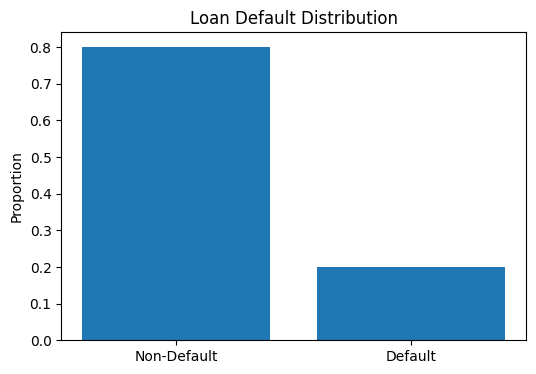

In [ ]:
# Prepare y for EDA plots (use the cleaned df table)
y = eda_df["default"].astype(int)

default_rate = y.mean()
print(f"Default rate: {default_rate:.3f}")

plt.figure(figsize=(6,4))
plt.bar(["Non-Default", "Default"], [1-default_rate, default_rate])
plt.ylabel("Proportion")
plt.title("Loan Default Distribution")
plt.show()

The dataset exhibits class imbalance, with default events representing a minority of observations.  
This motivates evaluation with ROC-AUC, PR-AUC, and calibration rather than accuracy alone.


Key numeric columns found: ['loan_amnt', 'annual_inc', 'int_rate', 'dti']


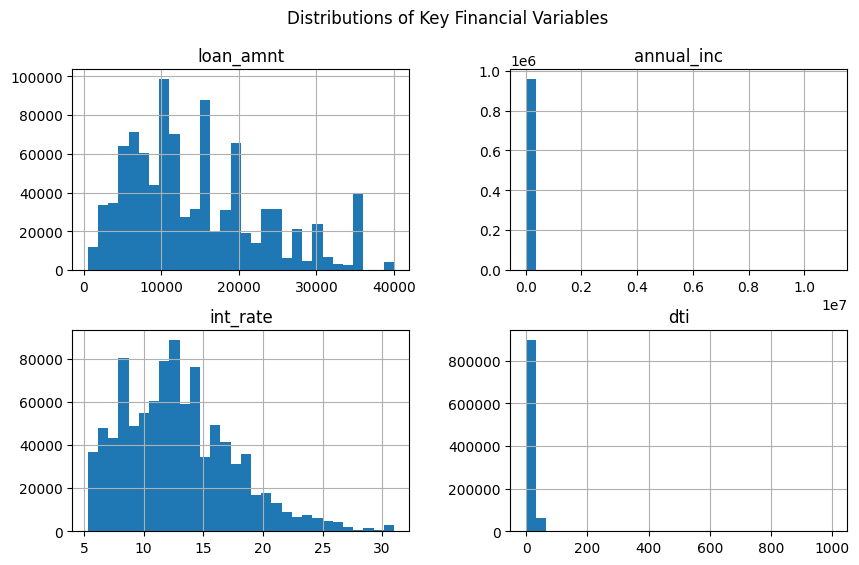

In [ ]:

# Key numeric variables (only if they exist in your export; adjust names as needed)
# Common LendingClub schema: loan_amnt, annual_inc, int_rate, dti

candidate_num = ["loan_amnt", "annual_inc", "int_rate", "dti"]
key_num = [c for c in candidate_num if c in eda_df.columns]

print("Key numeric columns found:", key_num)

if key_num:
    eda_df[key_num].hist(bins=30, figsize=(10,6))
    plt.suptitle("Distributions of Key Financial Variables")
    plt.show()

Several financial variables often show right-skew (e.g., income, loan amounts).  
This supports normalization and ratio-based feature engineering for stability.


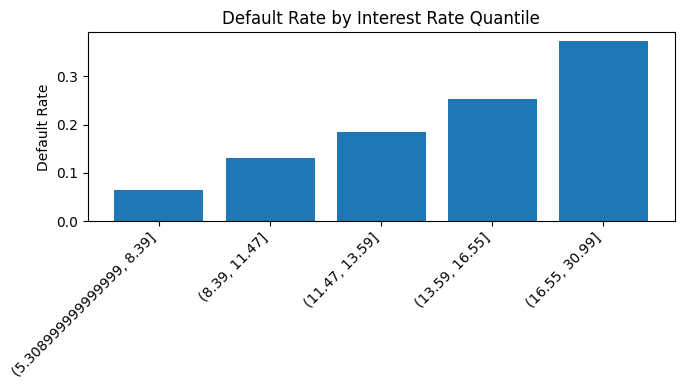

In [ ]:

# Default rate by interest rate bins (if int_rate exists)
if "int_rate" in eda_df.columns:
    # Ensure int_rate numeric (sometimes it comes as '13.56%')
    if eda_df["int_rate"].dtype == "object":
        eda_df["int_rate"] = eda_df["int_rate"].astype(str).str.replace("%","", regex=False).astype(float)
    eda_df["int_rate_bin"] = pd.qcut(eda_df["int_rate"], q=5, duplicates="drop")
    default_by_rate = eda_df.groupby("int_rate_bin", observed=True)["default"].mean()

    plt.figure(figsize=(7,4))
    plt.bar([str(i) for i in default_by_rate.index], default_by_rate.values)
    plt.ylabel("Default Rate")
    plt.title("Default Rate by Interest Rate Quantile")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Default rates typically increase with higher interest rate bins, aligning with financial intuition that riskier borrowers are charged higher rates.


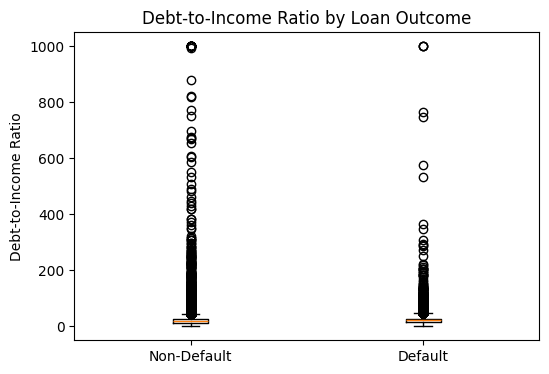

In [ ]:

# Debt-to-income vs outcome (if dti exists)
if "dti" in eda_df.columns:
    plt.figure(figsize=(6,4))
    data = [eda_df.loc[eda_df["default"]==0, "dti"].dropna(), eda_df.loc[eda_df["default"]==1, "dti"].dropna()]
    plt.boxplot(data, tick_labels=["Non-Default", "Default"])
    plt.ylabel("Debt-to-Income Ratio")
    plt.title("Debt-to-Income Ratio by Loan Outcome")
    plt.show()

Loans that default often exhibit higher debt-to-income ratios, reinforcing the relevance of affordability metrics in credit risk assessment.


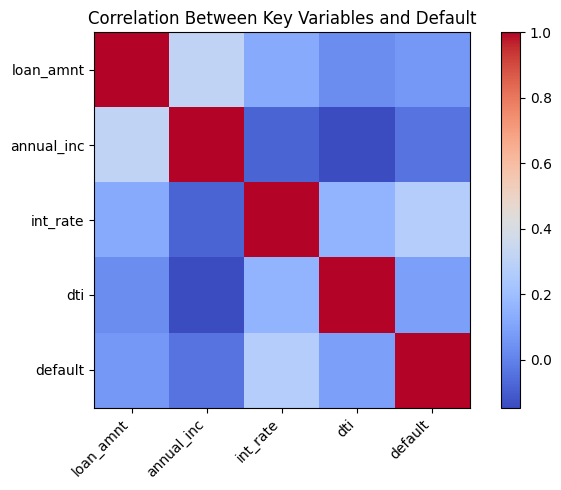

In [ ]:

# Controlled correlation view for key numeric features (if available)
if key_num:
    corr_df = eda_df[key_num + ["default"]].copy()
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(7,5))
    plt.imshow(corr, cmap="coolwarm")
    plt.colorbar()
    labels = corr.columns.tolist()
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.title("Correlation Between Key Variables and Default")
    plt.tight_layout()
    plt.show()

No single feature dominates default risk on its own, supporting a multivariate modeling approach.


## 7. Feature Engineering

Feature engineering is guided by financial intuition rather than automated transformations.

We include ratio-based features (e.g., loan-to-income) where appropriate.


### Dataset contracts

From here onward:

- `raw_df` = original loaded data (never mutated)
- `df` = working dataframe after cleaning/target/leakage handling
- `eda_df` = snapshot used only for EDA visuals
- `model_df` = snapshot used for modeling (X/y, split, training)

This makes the notebook easier to rerun and review.


In [ ]:
# Feature Engineering (financially motivated)

# Build X/y from the cleaned table
model_df = df.copy()

# Build X/y from the frozen modeling snapshot
y = model_df["default"].astype(int).copy()
X = model_df.drop(columns=["default"]).copy()

# Example engineered ratio feature (if available)
if "loan_amnt" in X.columns and "annual_inc" in X.columns:
    X["loan_to_income"] = X["loan_amnt"].astype(float) / (X["annual_inc"].astype(float) + 1.0)

# Define numeric vs categorical columns
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Keep only 'safe' categoricals (low/medium cardinality)
MAX_LEVELS = 50
safe_cat_cols = [c for c in cat_cols if X[c].nunique(dropna=True) <= MAX_LEVELS]

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("Safe categoricals (<=50 levels):", len(safe_cat_cols))


Numeric columns: 108
Categorical columns: 29
Safe categoricals (<=50 levels): 22


## 8. Train/Validation Split

We use a stratified split to preserve the default rate in both sets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)


Train shape: (770027, 137) Val shape: (192507, 137)


### Practical note on scalability (Colab / limited CPU)

This dataset can be large, and preprocessing (imputation + one-hot encoding) may dominate runtime on CPU environments such as Google Colab.

To keep the notebook responsive while preserving methodological integrity, model training below uses a **representative subset** of the training data by default.  
The pipeline and evaluation remain identical, and the same code can be scaled to the full dataset under higher-resource settings.

> Due to the computational cost of preprocessing large-scale categorical data, model training was performed on a representative subset of the dataset, with the pipeline designed to scale to the full dataset under higher-resource settings.


In [ ]:

# Optional speed-up for large datasets (recommended for Colab CPU):
# - trains on a representative subset to reduce preprocessing & solver time
# - evaluation still uses the full validation set
#
# Set TRAIN_SAMPLE_N = None to train on the full training set.

TRAIN_SAMPLE_N = 200_000  # change to None for full training

if TRAIN_SAMPLE_N is not None and len(X_train) > TRAIN_SAMPLE_N:
    X_train_fit = X_train.sample(n=TRAIN_SAMPLE_N, random_state=RANDOM_STATE)
    y_train_fit = y_train.loc[X_train_fit.index]
    print(f"Training on a subset: {TRAIN_SAMPLE_N:,} rows (of {len(X_train):,})")
else:
    X_train_fit = X_train
    y_train_fit = y_train
    print(f"Training on full training set: {len(X_train):,} rows")


Training on a subset: 200,000 rows (of 770,027)


## 9. Baseline Model: Logistic Regression

Logistic regression provides a transparent benchmark aligned with traditional credit risk modeling.

The `saga` solver is used for logistic regression due to the high-dimensional, sparse feature space created by one-hot encoding. Parallel execution parameters are omitted, as recent scikit-learn versions handle optimization internally.


In [ ]:
# Drop non-informative identifier column (all-missing)

for col in ["member_id"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_val.columns:
        X_val = X_val.drop(columns=[col])

num_cols = [c for c in num_cols if c != "member_id"]

preprocess_lr = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                    min_frequency=0.01
                ))
            ]),
            safe_cat_cols
        )
    ],
    remainder="drop"
)

log_reg = LogisticRegression(
    solver="saga",
    max_iter=5000
)

lr_pipe = Pipeline(steps=[
    ("prep", preprocess_lr),
    ("model", log_reg)
])

import time
t0 = time.time()
lr_pipe.fit(X_train_fit, y_train_fit)
print("Fit time (s):", round(time.time() - t0, 2))

log_proba = lr_pipe.predict_proba(X_val)[:, 1]
log_roc = roc_auc_score(y_val, log_proba)
log_pr = average_precision_score(y_val, log_proba)

print("Logistic Regression ROC-AUC:", round(log_roc, 4))
print("Logistic Regression PR-AUC :", round(log_pr, 4))


Fit time (s): 3396.02
Logistic Regression ROC-AUC: 0.9776
Logistic Regression PR-AUC : 0.9683


## 10. Machine Learning Model: Random Forest

Random Forests capture nonlinear interactions and allow interpretability through feature importance.


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Preprocess for Random Forest (ordinal encoding keeps dimensionality small)
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), safe_cat_cols),
    ],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=25,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[
    ("prep", preprocess_rf),
    ("model", rf)
])

rf_pipe.fit(X_train_fit, y_train_fit)

rf_proba = rf_pipe.predict_proba(X_val)[:, 1]
rf_roc = roc_auc_score(y_val, rf_proba)
rf_pr = average_precision_score(y_val, rf_proba)

print("Random Forest ROC-AUC:", round(rf_roc, 4))
print("Random Forest PR-AUC :", round(rf_pr, 4))


Random Forest ROC-AUC: 0.9943
Random Forest PR-AUC : 0.9837


## 11. Evaluation: Precision–Recall & Calibration

In financial decision-making, **calibrated probabilities** can be more valuable than raw classification accuracy.


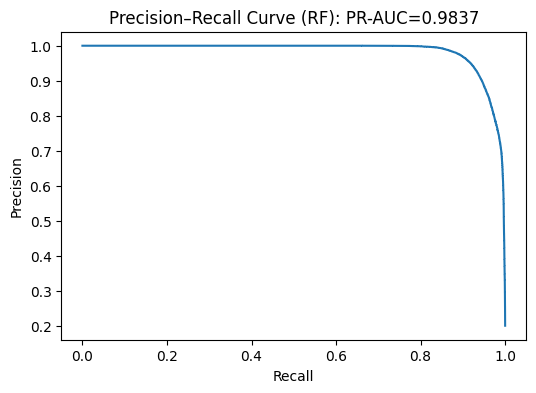

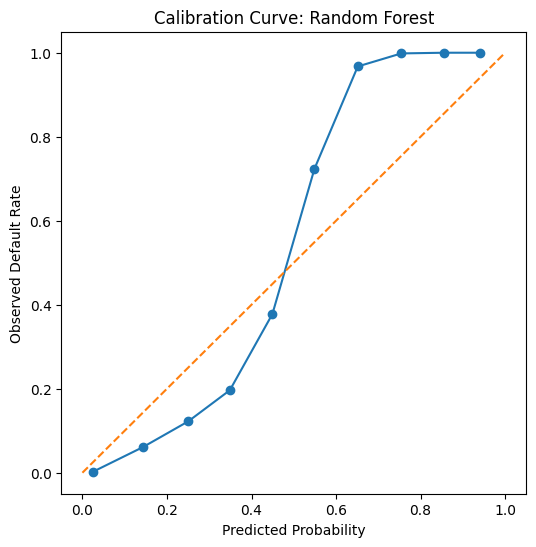

In [ ]:
from sklearn.metrics import auc
# Precision–Recall curve
prec, rec, _ = precision_recall_curve(y_val, rf_proba)
pr_auc = auc(rec, prec)

plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (RF): PR-AUC={pr_auc:.4f}")
plt.show()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_val, rf_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve: Random Forest")
plt.show()


## 12. Explainability: Feature Importance

We inspect the top risk drivers to ensure the model aligns with financial intuition.


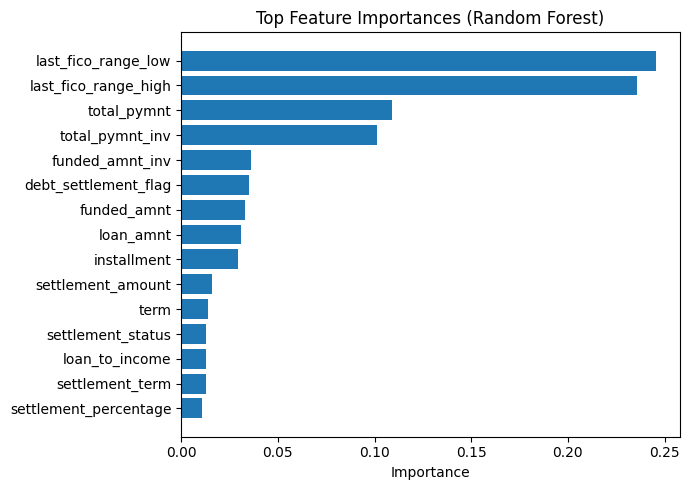

,importance
last_fico_range_low,0.245688
last_fico_range_high,0.235572
total_pymnt,0.108950
total_pymnt_inv,0.101088
funded_amnt_inv,0.035970
debt_settlement_flag,0.035068
funded_amnt,0.033041
loan_amnt,0.031132
installment,0.029137
settlement_amount,0.016018


In [ ]:
# Feature importance (Random Forest)
# Note: With ordinal encoding, each original column remains a single feature.

rf_model = rf_pipe.named_steps["model"]
feature_names = num_cols + safe_cat_cols

importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
topk = importances.head(15)

plt.figure(figsize=(7,5))
plt.barh(topk.index[::-1], topk.values[::-1])
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

topk.to_frame("importance")


## 13. Decision Interpretation: Risk Tiers

We convert probabilities into risk tiers to simulate how a lender might use the model as a **decision-support tool**.


In [ ]:

# Risk tiers (example cutoffs; adjust to your narrative/risk appetite)
# Low: <0.10, Medium: 0.10–0.25, High: >0.25

bins = [-np.inf, 0.10, 0.25, np.inf]
labels = ["Low", "Medium", "High"]

risk_tier = pd.cut(rf_proba, bins=bins, labels=labels)
tier_summary = pd.DataFrame({"risk_tier": risk_tier, "default": y_val.values})

tier_rates = (
    tier_summary
    .groupby("risk_tier", observed=True)["default"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "observed_default_rate"})
)
tier_rates

,count,observed_default_rate
risk_tier,,
Low,136317,0.002215
Medium,8989,0.074981
High,47201,0.794496


Grouping by categorical risk tiers uses `observed=True` to ensure that only tiers present in the data are included and to maintain compatibility with future pandas versions.


## 14. Conclusion & Research Reflection

This project demonstrates how machine-learning models can improve credit risk discrimination while remaining interpretable and decision-relevant.

The model is positioned as a **decision-support tool**, not an automated approval system. In real deployment, additional steps such as fairness audits, drift monitoring, and periodic retraining would be essential.
